# DILI prediction and context aware generation  
Dataset: https://github.com/bmil-jnu/InterDILI/tree/main

In [3]:
#import
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem, DataStructs, Draw
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image
import io

from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import cross_validate,cross_val_score, KFold
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.decomposition import PCA
import optuna
import shap
import subprocess, tempfile, os

In [4]:
def select_features_mi(X, y, keep_ratio=0.2):
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    y_disc = KBinsDiscretizer(n_bins=100, encode='ordinal', strategy='quantile').fit_transform(y.values.reshape(-1,1)).ravel()
    mi = mutual_info_regression(X, y_disc, random_state=42)
    mi = pd.Series(mi, index=X.columns)
    k = int(len(mi) * keep_ratio)
    selected_features = mi.sort_values(ascending=False).iloc[:k].index
    return X[selected_features], selected_features, mi

### Feature generation

In [2]:
datafile = pd.read_csv("Total_dataset_InterDILI.csv")

In [4]:
datafile.drop_duplicates().shape #no duplicate

(1850, 3)

In [5]:
datafile.isna().sum()

smiles      0
toxicity    0
ref         0
dtype: int64

In [6]:
datafile.toxicity.value_counts()

toxicity
1    952
0    898
Name: count, dtype: int64

In [7]:
data=datafile.copy()

In [8]:
#Number of atoms
def get_num_nodes(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return mol.GetNumAtoms() if mol else 0

In [52]:
#Generating Morgan Fingerprint
def smiles_to_fingerprint(smiles, radius=3, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    arr = np.zeros((1,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

In [10]:
smiles_list = datafile["smiles"].to_list()

In [24]:
fingerprints = np.array([smiles_to_fingerprint(s) for s in smiles_list if smiles_to_fingerprint(s) is not None])

[21:51:40] DEPRECATION WARNING: please use MorganGenerator
[21:51:40] DEPRECATION WARNING: please use MorganGenerator
[21:51:40] DEPRECATION WARNING: please use MorganGenerator
[21:51:40] DEPRECATION WARNING: please use MorganGenerator
[21:51:40] DEPRECATION WARNING: please use MorganGenerator
[21:51:40] DEPRECATION WARNING: please use MorganGenerator
[21:51:40] DEPRECATION WARNING: please use MorganGenerator
[21:51:40] DEPRECATION WARNING: please use MorganGenerator
[21:51:40] DEPRECATION WARNING: please use MorganGenerator
[21:51:40] DEPRECATION WARNING: please use MorganGenerator
[21:51:40] DEPRECATION WARNING: please use MorganGenerator
[21:51:40] DEPRECATION WARNING: please use MorganGenerator
[21:51:40] DEPRECATION WARNING: please use MorganGenerator
[21:51:40] DEPRECATION WARNING: please use MorganGenerator
[21:51:40] DEPRECATION WARNING: please use MorganGenerator
[21:51:40] DEPRECATION WARNING: please use MorganGenerator
[21:51:40] DEPRECATION WARNING: please use MorganGenerat

In [16]:
tsne = TSNE(n_components=2, random_state=42, perplexity=42) #https://scikit-learn.org/stable/auto_examples/manifold/plot_t_sne_perplexity.html
embedding = tsne.fit_transform(fingerprints)

In [17]:
df = pd.DataFrame(embedding, columns=["X", "Y"])

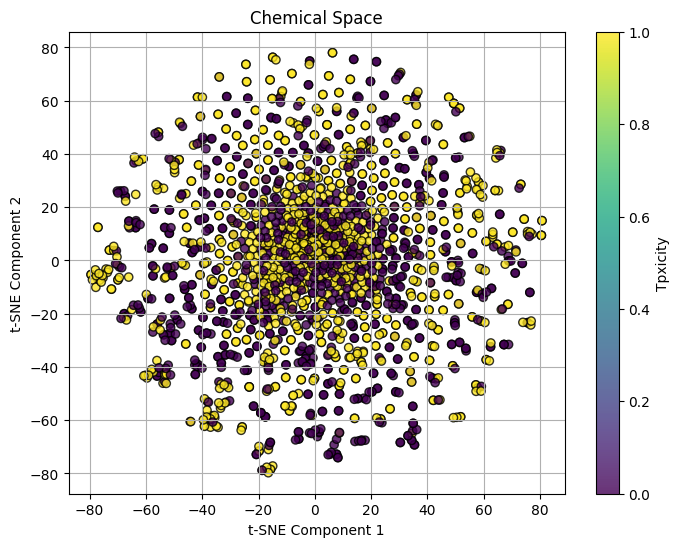

In [18]:
property_values = datafile["toxicity"].to_list()
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df["X"], df["Y"],  c=property_values, cmap='viridis', edgecolors='k', alpha=0.8)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("Chemical Space")
plt.colorbar(scatter, label='Tpxicity')
plt.grid(True)
plt.show()

In [25]:
fingerprints = pd.DataFrame(fingerprints)
fingerprints["SMILES"] = smiles_list

In [26]:
fingerprints["toxicity"] = datafile["toxicity"]

In [29]:
def generate_2d_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {desc_name: func(mol) for desc_name, func in Descriptors.descList}

In [30]:
def generate_3d_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None 
    mol = Chem.AddHs(mol)  
    try:
        AllChem.EmbedMolecule(mol, AllChem.ETKDG())
        AllChem.UFFOptimizeMolecule(mol)
        descriptors_3d = {
            "radius_of_gyration": rdMolDescriptors.CalcRadiusOfGyration(mol),
            "asphericity": rdMolDescriptors.CalcAsphericity(mol),
            "spherocity_index": rdMolDescriptors.CalcSpherocityIndex(mol),
            "eccentricity": rdMolDescriptors.CalcEccentricity(mol),
            "NPR1": rdMolDescriptors.CalcNPR1(mol),
            "NPR2": rdMolDescriptors.CalcNPR2(mol),
            "PMI1": rdMolDescriptors.CalcPMI1(mol),
            "PMI2": rdMolDescriptors.CalcPMI2(mol),
            "PMI3": rdMolDescriptors.CalcPMI3(mol)}
        return descriptors_3d
    except:
        return None 

In [31]:
data = []
for smiles in smiles_list:
    descriptors_2d = generate_2d_descriptors(smiles)
    descriptors_3d = generate_3d_descriptors(smiles)
    if descriptors_2d and descriptors_3d:
        combined_descriptors = {**descriptors_2d, **descriptors_3d}
        combined_descriptors["SMILES"] = smiles
        data.append(combined_descriptors)

[22:03:55] UFFTYPER: Unrecognized atom type: Pt3+2 (0)
[22:03:55] UFFTYPER: Unrecognized atom type: Pt3+2 (14)
[22:04:24] UFFTYPER: Unrecognized atom type: Co2+3 (0)
[22:04:24] UFFTYPER: Unrecognized atom type: Co2+3 (92)
[22:04:29] UFFTYPER: Warning: hybridization set to SP3 for atom 1
[22:04:29] UFFTYPER: Warning: hybridization set to SP3 for atom 11
[22:04:41] UFFTYPER: Warning: hybridization set to SP3 for atom 0
[22:04:41] UFFTYPER: Unrecognized charge state for atom: 0
[22:04:41] UFFTYPER: Warning: hybridization set to SP3 for atom 57
[22:04:41] UFFTYPER: Unrecognized charge state for atom: 57
[22:04:41] UFFTYPER: Unrecognized charge state for atom: 0
[22:04:41] UFFTYPER: Unrecognized atom type: La+3 (0)
[22:04:41] UFFTYPER: Unrecognized charge state for atom: 0
[22:04:41] UFFTYPER: Unrecognized atom type: La+3 (0)
[22:04:41] UFFTYPER: Unrecognized charge state for atom: 13
[22:04:41] UFFTYPER: Unrecognized atom type: La+3 (13)
[22:04:41] UFFTYPER: Unrecognized charge state for a

In [32]:
df = pd.DataFrame(data)

In [33]:
data = fingerprints.merge(df,on="SMILES").drop_duplicates()

In [34]:
data.set_index("SMILES",inplace=True)

In [48]:
data.isna().sum().sum()

0

In [49]:
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.fillna(data.mean(), inplace=True) 

In [58]:
data.to_csv("feature_data.csv")

### Model building 1

In [2]:
data = pd.read_csv("feature_data.csv")

In [3]:
data.set_index("SMILES",inplace=True)

In [4]:
print(data.shape)
print("Removing features with zero variance")
data = data.loc[:, data.var() !=0] 
print(data.shape)
print("Removing feature with less then 0.1 correlation")
cor = data.corr()["toxicity"]
data = data[cor[cor>0.01].index]
print(data.shape)

(1836, 2268)
Removing features with zero variance
(1836, 2263)
Removing feature with less then 0.1 correlation


C:\Users\shasa\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


(1836, 901)


In [5]:
X = data.drop(["toxicity"],axis=1)
y =data["toxicity"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
scaler = StandardScaler().fit(X_train.values)
X_train = pd.DataFrame(scaler.transform(X_train.values),  columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test.values), columns=X.columns)

In [8]:
model = xgb.XGBClassifier( n_estimators=1000,random_state=42, learning_rate=0.01, max_depth=8)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'accuracy': 'accuracy',  'f1': 'f1', 'roc_auc': 'roc_auc'}

cv_results = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True, return_estimator=True)

train_acc_mean = cv_results['train_accuracy'].mean()
train_acc_std = cv_results['train_accuracy'].std()
train_f1_mean = cv_results['train_f1'].mean()
train_f1_std = cv_results['train_f1'].std()
train_auc_mean = cv_results['train_roc_auc'].mean()
train_auc_std = cv_results['train_roc_auc'].std()

test_acc_mean = cv_results['test_accuracy'].mean()
test_acc_std = cv_results['test_accuracy'].std()
test_f1_mean = cv_results['test_f1'].mean()
test_f1_std = cv_results['test_f1'].std()
test_auc_mean = cv_results['test_roc_auc'].mean()
test_auc_std = cv_results['test_roc_auc'].std()

print("Cross-Validation Performance:")
print(f"Training Accuracy: {train_acc_mean:.4f} (±{train_acc_std:.4f})")
#print(f"Training F1: {train_f1_mean:.4f} (±{train_f1_std:.4f})")
#print(f"Training AUC: {train_auc_mean:.4f} (±{train_auc_std:.4f})")
print(f"Validation Accuracy: {test_acc_mean:.4f} (±{test_acc_std:.4f})")
#print(f"Validation F1: {test_f1_mean:.4f} (±{test_f1_std:.4f})")
#print(f"Validation AUC: {test_auc_mean:.4f} (±{test_auc_std:.4f})\n")


model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]
acc_test = accuracy_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
auc_test = roc_auc_score(y_test, y_pred_prob)
print("Final Test Performance:")
print(f"Accuracy: {acc_test:.4f}")
#print(f"F1 Score: {f1_test:.4f}")
#print(f"ROC-AUC: {auc_test:.4f}")

Cross-Validation Performance:
Training Accuracy: 0.9928 (±0.0026)
Validation Accuracy: 0.7561 (±0.0080)
Final Test Performance:
Accuracy: 0.7609


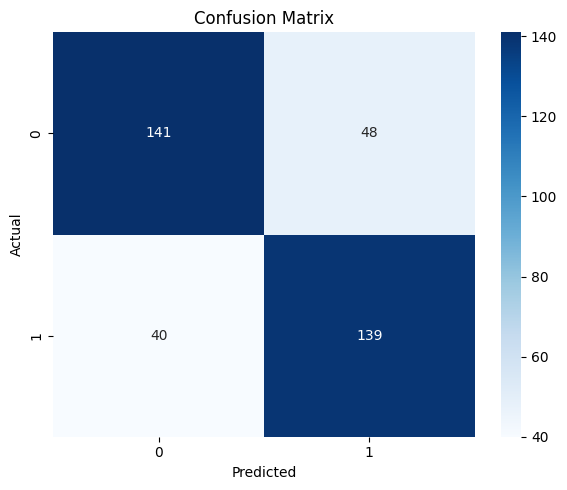

In [15]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [17]:
explainer = shap.Explainer(model)
shap_values = explainer(X_train)

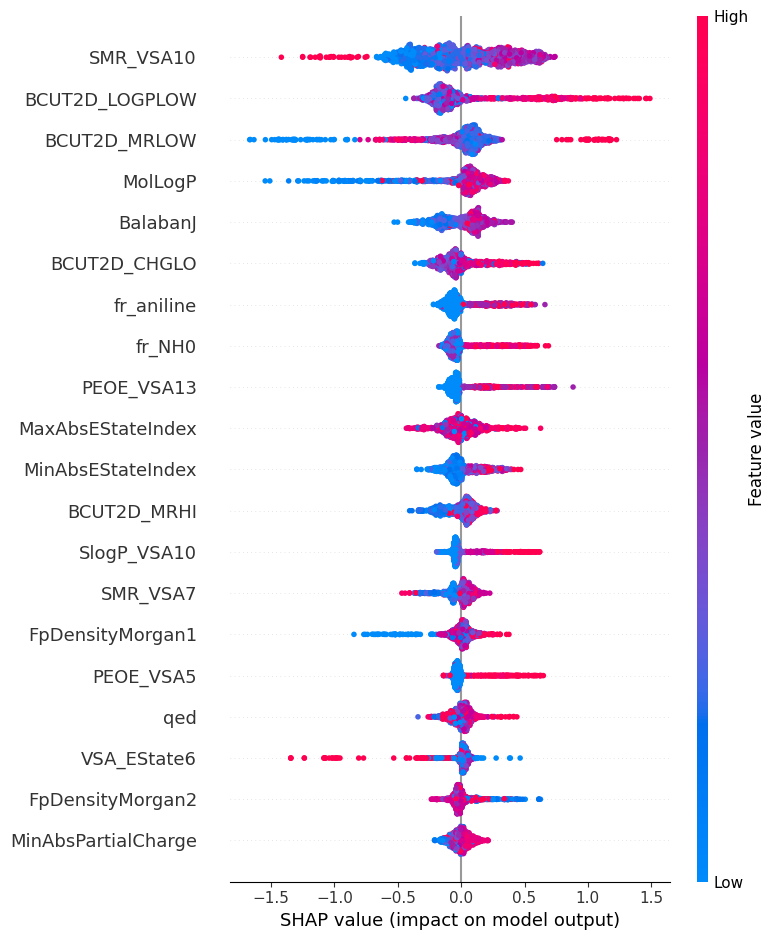

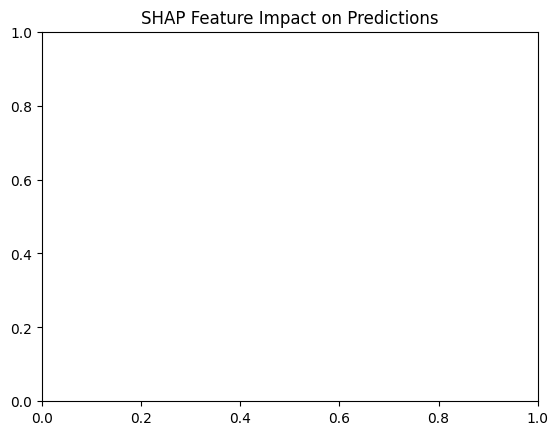

In [18]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train)
plt.title("SHAP Feature Impact on Predictions")
plt.show()

In [105]:
def objective(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1500, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 15, step=1),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, step=0.01),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0, step=0.05),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0, step=0.05),
        "gamma": trial.suggest_float("gamma", 0, 5, step=0.1),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10, step=1),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5, step=0.1),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5, step=0.1),}
    model = xgb.XGBClassifier(**param,objective='binary:logistic',random_state=42,n_jobs=-1,eval_metric='logloss')
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="roc_auc")
    return scores.mean()

In [106]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("Best trial:")
print(f"  Best ROC-AUC (CV): {study.best_trial.value:.4f}")
print(f"  Params: {study.best_trial.params}")
best_params = study.best_trial.params
best_model = xgb.XGBClassifier(**best_params,objective='binary:logistic',random_state=42, n_jobs=-1, eval_metric='logloss')
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

acc_test = accuracy_score(y_test, y_pred)
f1_test = f1_score(y_test, y_pred)
auc_test = roc_auc_score(y_test, y_pred_prob)

print(f"\nTest Accuracy: {acc_test:.4f}")
print(f"Test F1: {f1_test:.4f}")
print(f"Test ROC-AUC: {auc_test:.4f}")

[I 2025-12-12 00:17:38,028] A new study created in memory with name: no-name-e5ce293c-2b2b-49f9-b6f2-0cf80cf55260
[I 2025-12-12 00:17:53,449] Trial 0 finished with value: 0.7684039446281267 and parameters: {'n_estimators': 1100, 'max_depth': 10, 'learning_rate': 0.14, 'subsample': 0.7, 'colsample_bytree': 0.6000000000000001, 'gamma': 1.8, 'min_child_weight': 8, 'reg_alpha': 3.8000000000000003, 'reg_lambda': 0.5}. Best is trial 0 with value: 0.7684039446281267.
[I 2025-12-12 00:17:58,510] Trial 1 finished with value: 0.737434092943492 and parameters: {'n_estimators': 300, 'max_depth': 14, 'learning_rate': 0.09, 'subsample': 0.5, 'colsample_bytree': 0.9000000000000001, 'gamma': 4.2, 'min_child_weight': 10, 'reg_alpha': 4.2, 'reg_lambda': 2.7}. Best is trial 0 with value: 0.7684039446281267.
[I 2025-12-12 00:18:01,333] Trial 2 finished with value: 0.7660794832922937 and parameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.11, 'subsample': 0.5, 'colsample_bytree': 0.8, 'gam

Best trial:
  Best ROC-AUC (CV): 0.8182
  Params: {'n_estimators': 900, 'max_depth': 9, 'learning_rate': 0.01, 'subsample': 0.8500000000000001, 'colsample_bytree': 0.4, 'gamma': 0.30000000000000004, 'min_child_weight': 2, 'reg_alpha': 0.2, 'reg_lambda': 0.7000000000000001}

Test Accuracy: 0.7636
Test F1: 0.7603
Test ROC-AUC: 0.8429


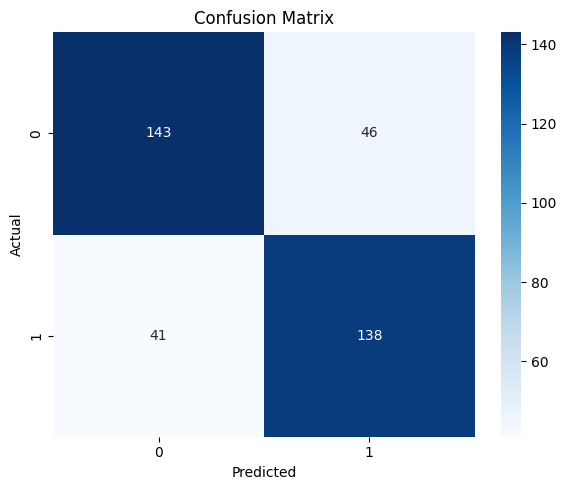

In [107]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [108]:
explainer = shap.Explainer(best_model)
shap_values = explainer(X_train)

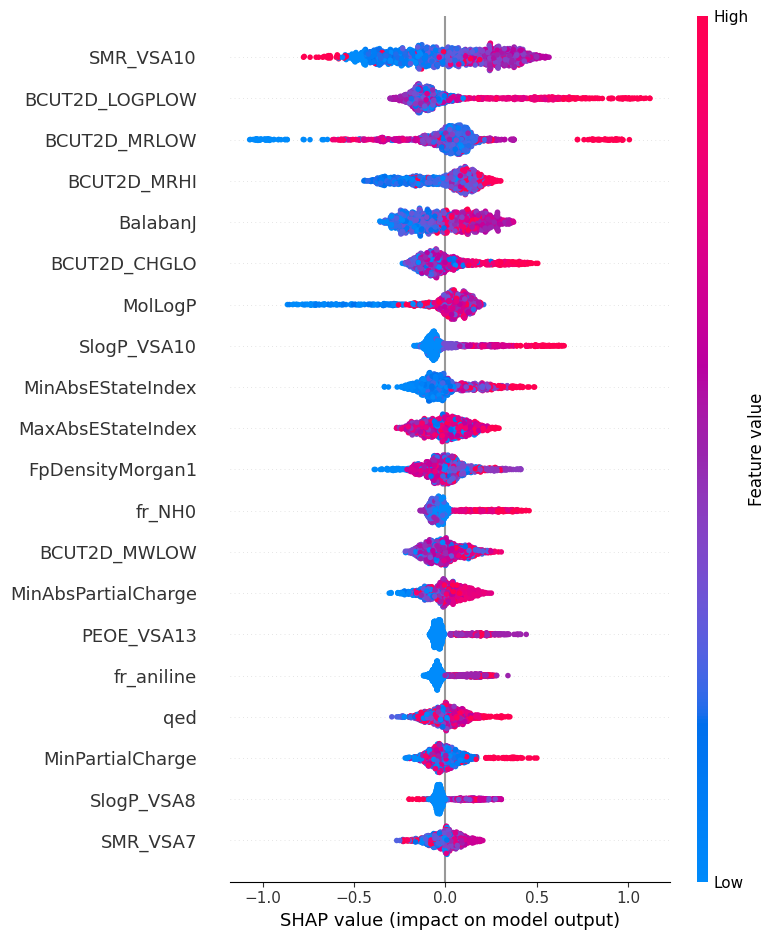

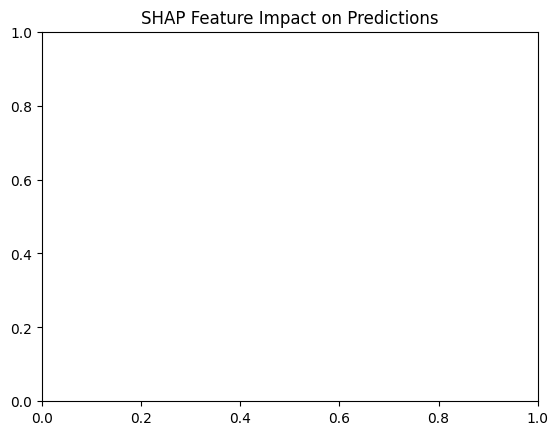

In [109]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train)
plt.title("SHAP Feature Impact on Predictions")
plt.show()

### Model building 2

In [5]:
#TOXICOPHORE FEATURES
TOXICOPHORE_SMARTS = {
    # Aromatic bioactivation
    "aniline": "c[NH2]",
    "heteroaromatic_amine": "[nH]c",
    "indole": "c1cc2ccccc2[nH]1",
    "pyrrole": "[nH]1cccc1",

    # Sulfur / oxygen heterocycles
    "thiophene": "c1ccsc1",
    "furan": "c1ccoc1",

    # Electrophiles
    "michael_acceptor": "C=CC=O",
    "epoxide": "C1OC1",
    "aldehyde": "[CX3H1](=O)",
    "acyl_halide": "C(=O)[F,Cl,Br,I]",
    "isocyanate": "N=C=O",

    # Redox-active
    "quinone": "O=C1C=CC(=O)C=C1",
    "catechol": "c1ccc(O)cc1O",
    "hydroquinone": "c1ccc(O)cc1O",

    # Other
    "nitro": "[N+](=O)[O-]",
    "sulfonamide": "S(=O)(=O)N",
    "thioamide": "C(=S)N"
}


def toxicophore_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    features = {}
    for name, smarts in TOXICOPHORE_SMARTS.items():
        patt = Chem.MolFromSmarts(smarts)
        features[name] = 1 if mol.HasSubstructMatch(patt) else 0
    return [i for i in features.values()]

In [6]:
# CONFORMAL PREDICTION
class ConformalPredictor:
    def __init__(self, model):
        self.model = model
        self.calibration_scores = None
    def fit(self, X_train, y_train, X_cal, y_cal):
        self.model.fit(X_train, y_train)
        # calibration: compute nonconformity scores
        probs = self.model.predict_proba(X_cal)[:, 1]
        self.calibration_scores = np.abs(probs - y_cal)
    def predict(self, X_test, alpha=0.1):
        probs = self.model.predict_proba(X_test)[:, 1]
        intervals = []
        q = np.quantile(self.calibration_scores, 1 - alpha)
        for p in probs:
            low = max(0, p - q)
            high = min(1, p + q)
            intervals.append((low, high))
        return intervals

In [7]:
tox_sub = [i for i in TOXICOPHORE_SMARTS.keys()]

In [15]:
data = pd.read_csv("feature_data.csv")
data.set_index("SMILES",inplace=True)

In [16]:
sub_feature = pd.DataFrame(data.index.values.tolist(),columns=["SMILES"])

In [17]:
sud_data = pd.DataFrame([i for i in sub_feature["SMILES"].apply(toxicophore_features)],columns=tox_sub,index=sub_feature["SMILES"])

In [18]:
final = pd.concat([data.drop(["toxicity"],axis=1),sud_data],axis=1)

In [19]:
final["toxicity"] = y

In [20]:
print(final.shape)
print("Removing features with zero variance")
data = final.loc[:, final.var() !=0] 
print(data.shape)
print("Removing feature with less then 0.1 correlation")
cor = data.corr()["toxicity"]
data = data[cor[cor>0.1].index]
print(data.shape)

(1836, 2285)
Removing features with zero variance
(1836, 2278)
Removing feature with less then 0.1 correlation


C:\Users\shasa\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


(1836, 26)


In [21]:
data.columns

Index(['4', '233', '378', '456', '552', '1488', '1683', '1825', 'BCUT2D_MWLOW',
       'BCUT2D_CHGLO', 'BCUT2D_LOGPLOW', 'BCUT2D_MRLOW', 'PEOE_VSA13',
       'PEOE_VSA3', 'PEOE_VSA5', 'SlogP_VSA10', 'SlogP_VSA8', 'VSA_EState10',
       'NumAromaticHeterocycles', 'NumAromaticRings', 'fr_Ar_N', 'fr_NH0',
       'fr_aniline', 'fr_hdrzine', 'fr_nitro', 'toxicity'],
      dtype='object')

In [22]:
X = data.drop(["toxicity"],axis=1)
y =data["toxicity"]

Cross-Validation Performance:
Training Accuracy: 0.9649 (±0.0029)
Validation Accuracy: 0.7391 (±0.0287)
Final Test Performance:
Accuracy: 0.7554


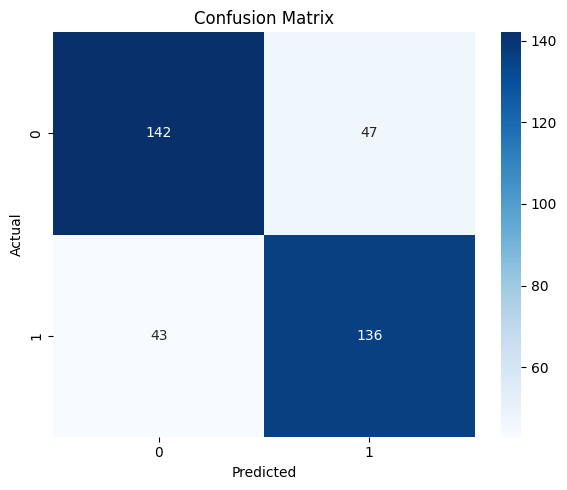

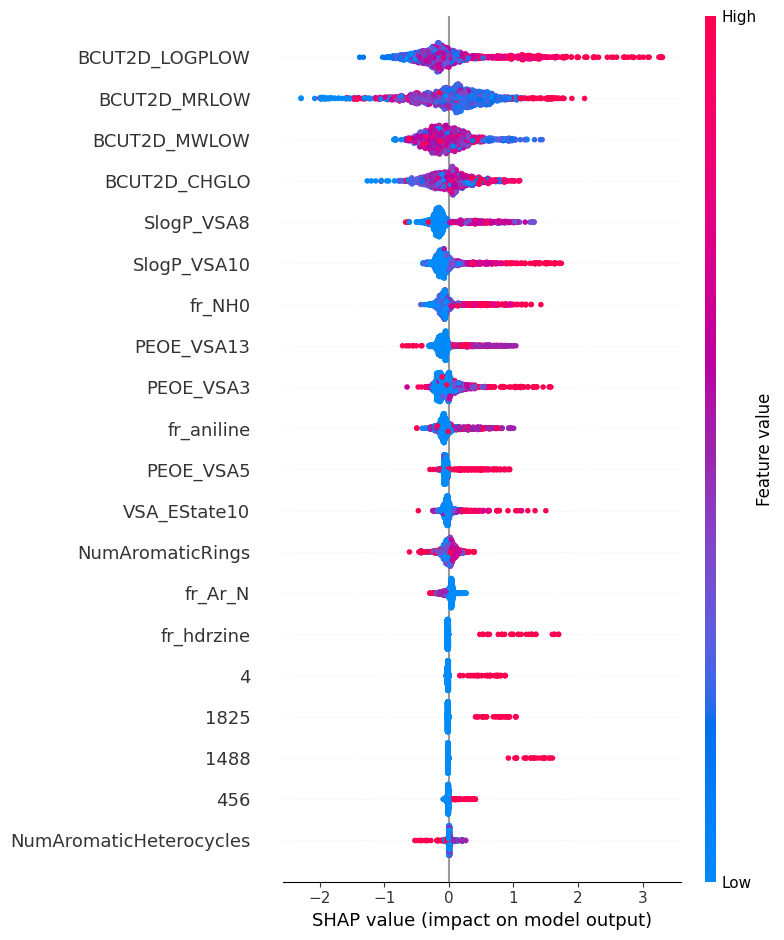

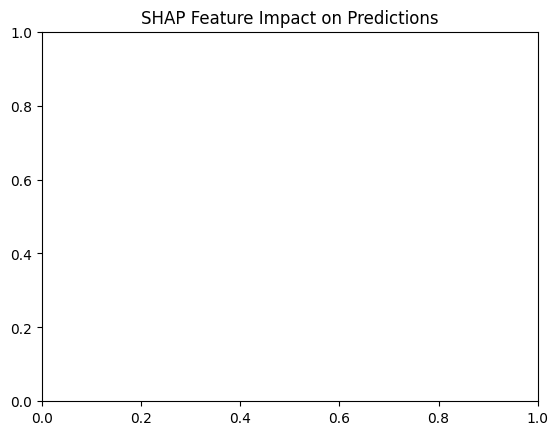

In [23]:
#X, selected_bits, mi_scores = select_features_mi(final, y, keep_ratio=0.5)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = xgb.XGBClassifier( n_estimators=1000,random_state=42, learning_rate=0.01, max_depth=8)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'accuracy': 'accuracy',  'f1': 'f1', 'roc_auc': 'roc_auc'}
cv_results = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True, return_estimator=True)

train_acc_mean = cv_results['train_accuracy'].mean()
train_acc_std = cv_results['train_accuracy'].std()
train_f1_mean = cv_results['train_f1'].mean()
train_f1_std = cv_results['train_f1'].std()
train_auc_mean = cv_results['train_roc_auc'].mean()
train_auc_std = cv_results['train_roc_auc'].std()
test_acc_mean = cv_results['test_accuracy'].mean()
test_acc_std = cv_results['test_accuracy'].std()
test_f1_mean = cv_results['test_f1'].mean()
test_f1_std = cv_results['test_f1'].std()
test_auc_mean = cv_results['test_roc_auc'].mean()
test_auc_std = cv_results['test_roc_auc'].std()

print("Cross-Validation Performance:")
print(f"Training Accuracy: {train_acc_mean:.4f} (±{train_acc_std:.4f})")
print(f"Validation Accuracy: {test_acc_mean:.4f} (±{test_acc_std:.4f})")


model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]
acc_test = accuracy_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)
auc_test = roc_auc_score(y_test, y_pred_prob)
print("Final Test Performance:")
print(f"Accuracy: {acc_test:.4f}")


cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


explainer = shap.Explainer(model)
shap_values = explainer(X_train)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train)
plt.title("SHAP Feature Impact on Predictions")
plt.show()

In [25]:
def evaluate_model(model, X_train, y_train, X_test, y_test, name):
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scoring = {'accuracy': 'accuracy', 'f1': 'f1', 'roc_auc': 'roc_auc'}

    cv_results = cross_validate(
        model,
        X_train, y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True
    )

    print(f"\n===== {name} (CV) =====")
    print(f"Train AUC: {cv_results['train_roc_auc'].mean():.3f}")
    print(f"Val   AUC: {cv_results['test_roc_auc'].mean():.3f}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"{name} (Test)")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

    return model

In [26]:
X = data.drop(["toxicity"],axis=1)
y =data["toxicity"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(X_train.values)
X_train = pd.DataFrame(scaler.transform(X_train.values),  columns=X.columns)
X_test = pd.DataFrame(scaler.transform(X_test.values), columns=X.columns)

In [34]:
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import ExtraTreesClassifier
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression


===== ElasticNet Logistic Regression (CV) =====
Train AUC: 0.736
Val   AUC: 0.719
ElasticNet Logistic Regression (Test)
Accuracy: 0.6630434782608695
F1: 0.630952380952381
ROC-AUC: 0.6975407170937897


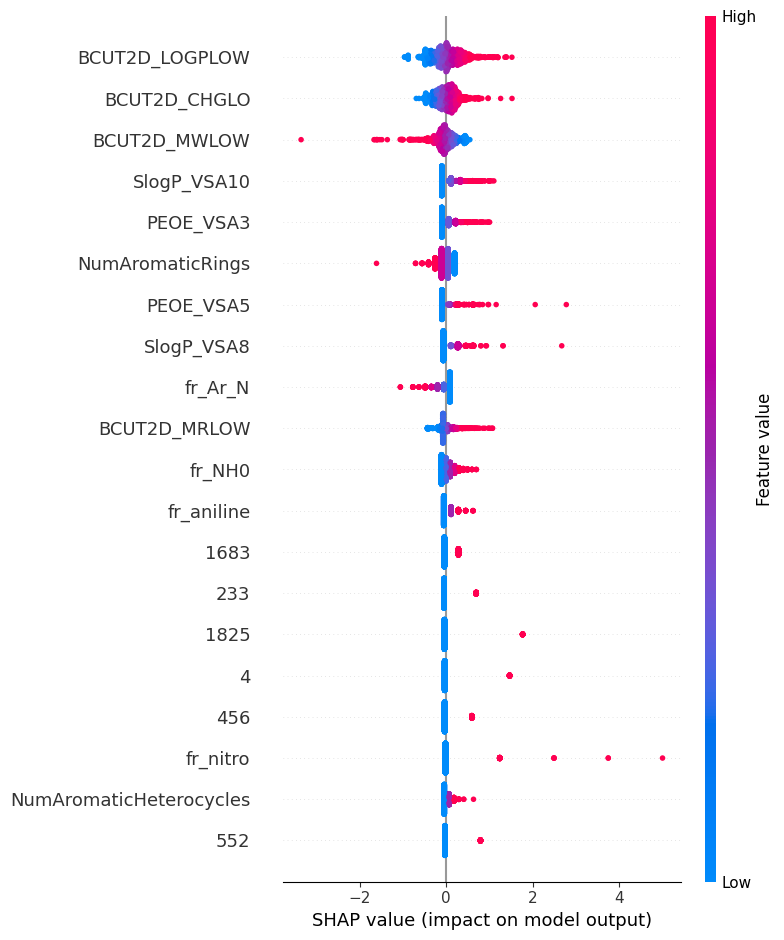

In [48]:
log_reg = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    l1_ratio=0.5,
    C=1.0,
    max_iter=5000,
    class_weight="balanced",
    random_state=42)

log_reg = evaluate_model(log_reg, X_train, y_train, X_test, y_test, name="ElasticNet Logistic Regression")
explainer = shap.LinearExplainer(log_reg, X_train)
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train)

In [36]:
svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    class_weight="balanced",
    random_state=42)

svm = evaluate_model(
    svm, X_train, y_train, X_test, y_test,
    name="SVM (RBF)")


===== SVM (RBF) (CV) =====
Train AUC: 0.913
Val   AUC: 0.758
SVM (RBF) (Test)
Accuracy: 0.7282608695652174
F1: 0.6987951807228915
ROC-AUC: 0.7868375158877953


In [37]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42)

rf = evaluate_model(
    rf, X_train, y_train, X_test, y_test,
    name="Random Forest")


===== Random Forest (CV) =====
Train AUC: 0.949
Val   AUC: 0.793
Random Forest (Test)
Accuracy: 0.7418478260869565
F1: 0.7323943661971831
ROC-AUC: 0.8134846738198693


In [38]:
lgbm = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42)

lgbm = evaluate_model(
    lgbm, X_train, y_train, X_test, y_test,
    name="LightGBM")

[LightGBM] [Info] Number of positive: 633, number of negative: 541
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002480 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1396
[LightGBM] [Info] Number of data points in the train set: 1174, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 622, number of negative: 552
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000725 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1394
[LightGBM] [Info] Number of data points in the train set: 1174, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Inf

In [39]:
et = ExtraTreesClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42)

et = evaluate_model(
    et, X_train, y_train, X_test, y_test,
    name="ExtraTrees")


===== ExtraTrees (CV) =====
Train AUC: 0.886
Val   AUC: 0.781
ExtraTrees (Test)
Accuracy: 0.7282608695652174
F1: 0.7126436781609194
ROC-AUC: 0.7858472998137803


In [43]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 16),
    activation="relu",
    alpha=1e-4,
    batch_size=128,
    learning_rate_init=1e-3,
    max_iter=300,
    early_stopping=True,
    random_state=42)

mlp = evaluate_model(
    mlp, X_train, y_train, X_test, y_test,
    name="MLP")


===== MLP (CV) =====
Train AUC: 0.818
Val   AUC: 0.747
MLP (Test)
Accuracy: 0.7309782608695652
F1: 0.7044776119402985
ROC-AUC: 0.7756938902190299


### Substructure viz

In [49]:
def visualize_bit_substructures(smiles_list, bit_position, radius=3, n_bits=2048, mols_per_row=6):
    valid_mols = []
    valid_smiles = []
    
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            print(f"Invalid SMILES skipped: {smiles}")
            continue
        fp_array = smiles_to_fingerprint(smiles, radius, n_bits)
        if fp_array is not None and fp_array[bit_position] == 1:
            valid_mols.append(mol)
            valid_smiles.append(smiles)
    if not valid_mols:
        print(f"No molecules in the list have bit {bit_position} set")
        return
    
    n_mols = len(valid_mols)
    n_rows = math.ceil(n_mols / mols_per_row)
    fig, axs = plt.subplots(n_rows, mols_per_row, 
                           figsize=(4*mols_per_row, 4*n_rows),
                           squeeze=False)
    axs = axs.flatten()
    for i, (mol, smiles) in enumerate(zip(valid_mols, valid_smiles)):
        ax = axs[i]

        bitInfo = {}
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol, radius=radius, nBits=n_bits, bitInfo=bitInfo)
        
        atom_infos = bitInfo[bit_position]
        highlight_atoms = set()
        highlight_bonds = set()
        
        for atom_idx, env_radius in atom_infos:
            env = Chem.FindAtomEnvironmentOfRadiusN(mol, env_radius, atom_idx)
            highlight_bonds.update(env)
            for bond_idx in env:
                bond = mol.GetBondWithIdx(bond_idx)
                highlight_atoms.add(bond.GetBeginAtomIdx())
                highlight_atoms.add(bond.GetEndAtomIdx())
        
        drawer = rdMolDraw2D.MolDraw2DCairo(300, 300)
        rdMolDraw2D.PrepareAndDrawMolecule(
            drawer, mol, 
            highlightAtoms=list(highlight_atoms),
            highlightBonds=list(highlight_bonds),
            highlightAtomColors={idx: (0.8, 0.8, 0.8) for idx in highlight_atoms},
            highlightBondColors={idx: (0.8, 0.8, 0.8) for idx in highlight_bonds}
        )
        drawer.FinishDrawing()
        img = Image.open(io.BytesIO(drawer.GetDrawingText()))
        ax.imshow(img)
        ax.set_title(f"{smiles[:15]}...\nBit {bit_position}", fontsize=10)
        ax.axis('off')
        
    for j in range(i+1, len(axs)):
        axs[j].axis('off')
    plt.tight_layout()
    plt.show()

In [50]:
data.columns

Index(['4', '233', '378', '456', '552', '1488', '1683', '1825', 'BCUT2D_MWLOW',
       'BCUT2D_CHGLO', 'BCUT2D_LOGPLOW', 'BCUT2D_MRLOW', 'PEOE_VSA13',
       'PEOE_VSA3', 'PEOE_VSA5', 'SlogP_VSA10', 'SlogP_VSA8', 'VSA_EState10',
       'NumAromaticHeterocycles', 'NumAromaticRings', 'fr_Ar_N', 'fr_NH0',
       'fr_aniline', 'fr_hdrzine', 'fr_nitro', 'toxicity'],
      dtype='object')

In [ ]:
4, 1825, 1488, 456

[00:22:49] DEPRECATION WARNING: please use MorganGenerator
[00:22:49] DEPRECATION WARNING: please use MorganGenerator
[00:22:49] DEPRECATION WARNING: please use MorganGenerator
[00:22:49] DEPRECATION WARNING: please use MorganGenerator
[00:22:49] DEPRECATION WARNING: please use MorganGenerator
[00:22:49] DEPRECATION WARNING: please use MorganGenerator
[00:22:49] DEPRECATION WARNING: please use MorganGenerator
[00:22:49] DEPRECATION WARNING: please use MorganGenerator
[00:22:49] DEPRECATION WARNING: please use MorganGenerator
[00:22:49] DEPRECATION WARNING: please use MorganGenerator
[00:22:49] DEPRECATION WARNING: please use MorganGenerator
[00:22:49] DEPRECATION WARNING: please use MorganGenerator
[00:22:49] DEPRECATION WARNING: please use MorganGenerator
[00:22:49] DEPRECATION WARNING: please use MorganGenerator
[00:22:49] DEPRECATION WARNING: please use MorganGenerator
[00:22:49] DEPRECATION WARNING: please use MorganGenerator
[00:22:49] DEPRECATION WARNING: please use MorganGenerat

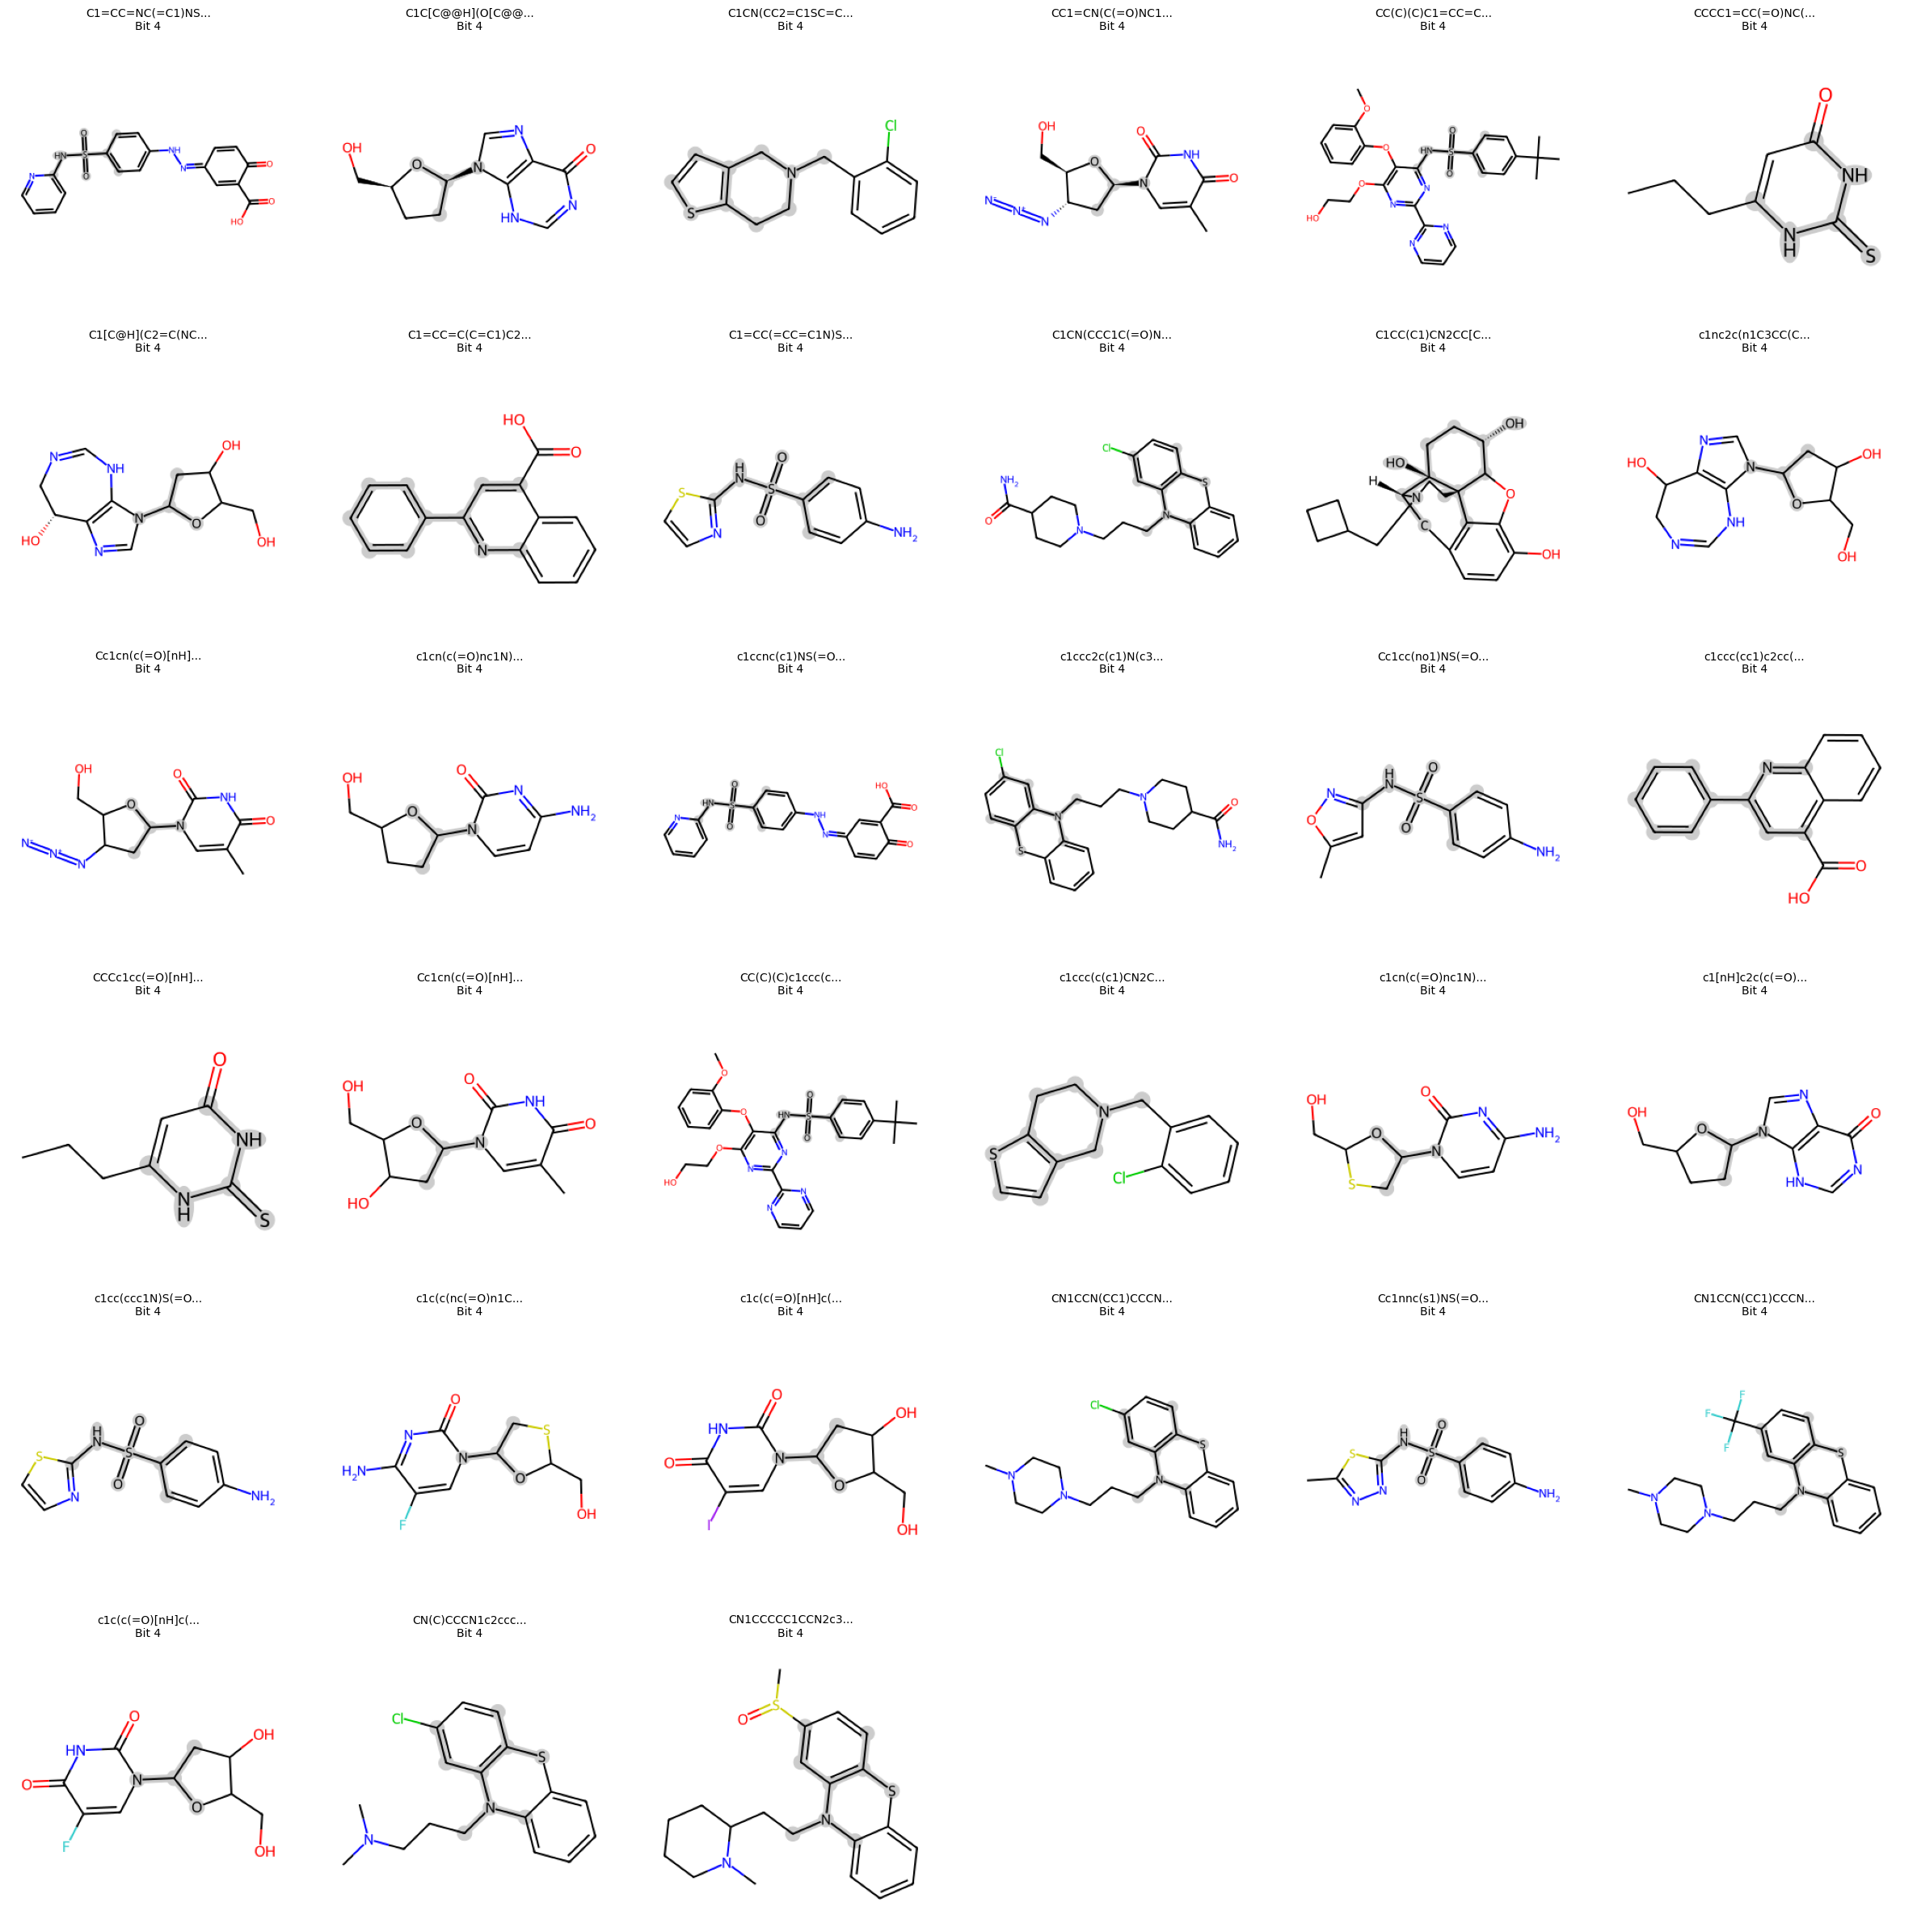

In [53]:
smiles_list = data.index.to_list()[:1000]
visualize_bit_substructures(smiles_list, bit_position=4) #c-c-o-

[00:22:54] DEPRECATION WARNING: please use MorganGenerator
[00:22:54] DEPRECATION WARNING: please use MorganGenerator
[00:22:54] DEPRECATION WARNING: please use MorganGenerator
[00:22:54] DEPRECATION WARNING: please use MorganGenerator
[00:22:54] DEPRECATION WARNING: please use MorganGenerator
[00:22:54] DEPRECATION WARNING: please use MorganGenerator
[00:22:54] DEPRECATION WARNING: please use MorganGenerator
[00:22:54] DEPRECATION WARNING: please use MorganGenerator
[00:22:54] DEPRECATION WARNING: please use MorganGenerator
[00:22:54] DEPRECATION WARNING: please use MorganGenerator
[00:22:54] DEPRECATION WARNING: please use MorganGenerator
[00:22:54] DEPRECATION WARNING: please use MorganGenerator
[00:22:54] DEPRECATION WARNING: please use MorganGenerator
[00:22:54] DEPRECATION WARNING: please use MorganGenerator
[00:22:54] DEPRECATION WARNING: please use MorganGenerator
[00:22:54] DEPRECATION WARNING: please use MorganGenerator
[00:22:54] DEPRECATION WARNING: please use MorganGenerat

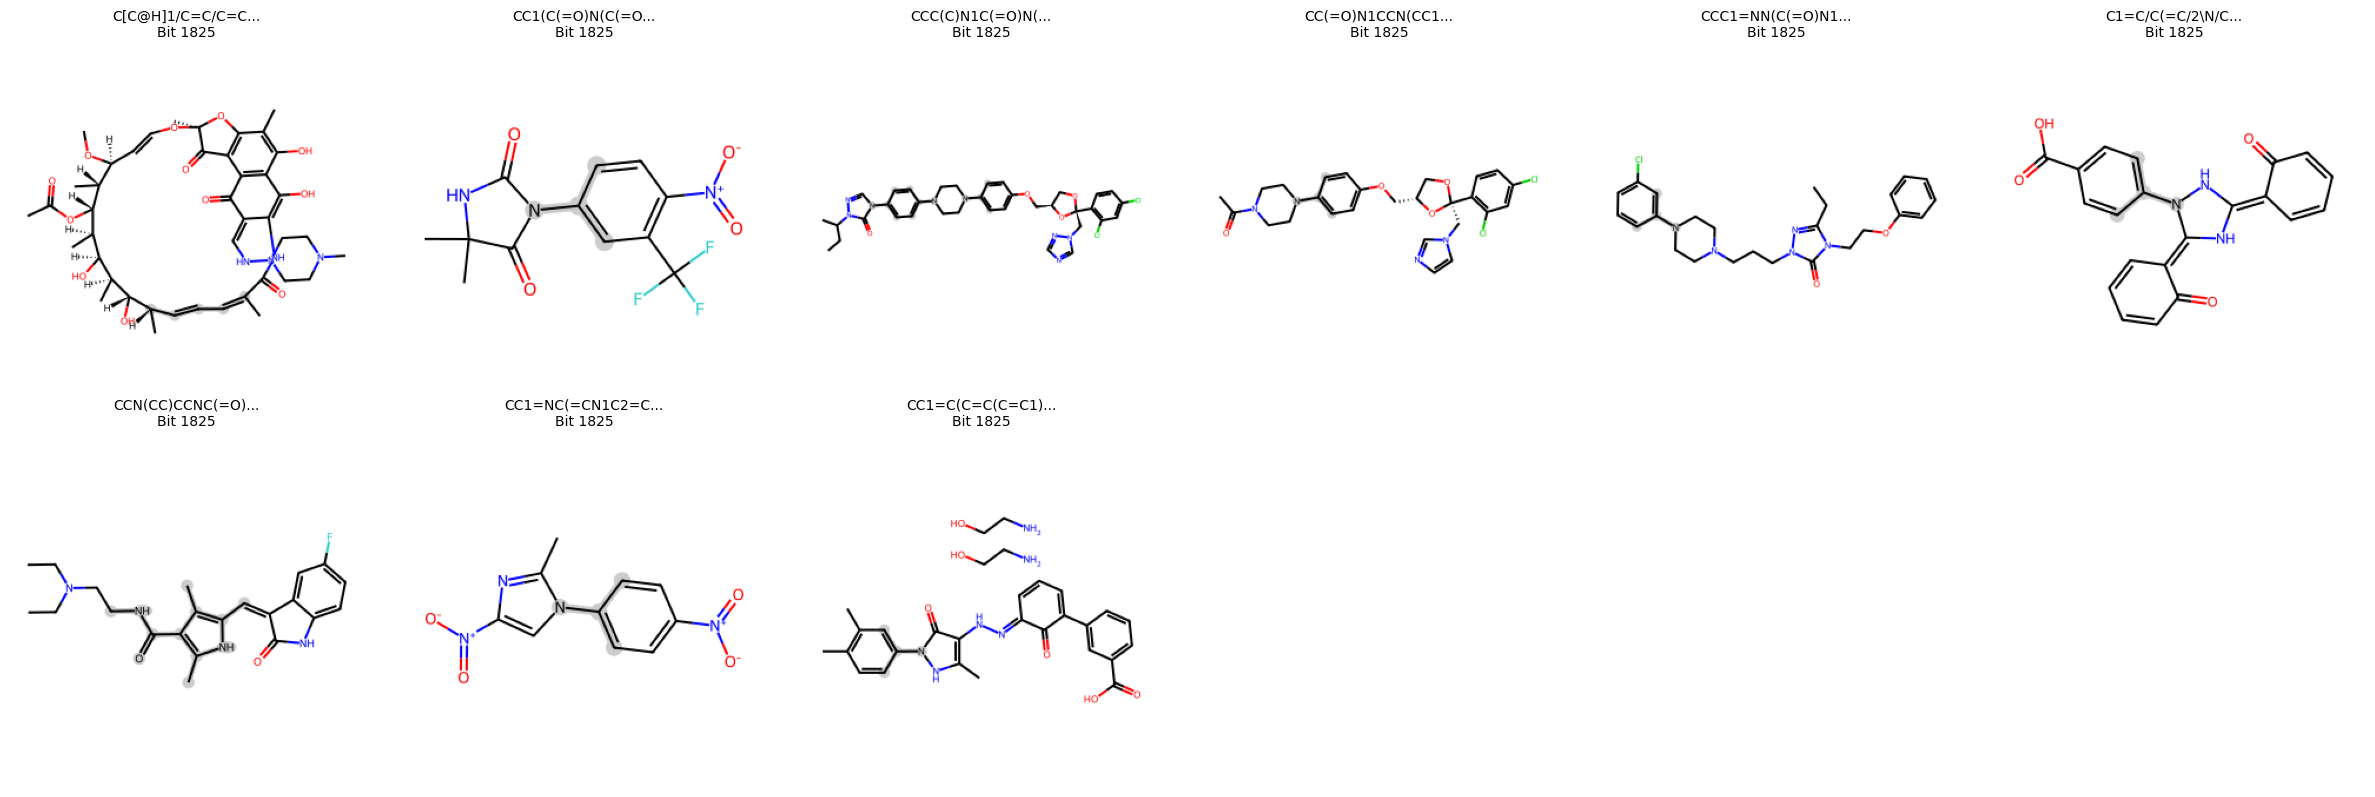

In [54]:
smiles_list = data.index.to_list()[:200]
visualize_bit_substructures(smiles_list, bit_position=1825) #c-c-o-

[00:22:56] DEPRECATION WARNING: please use MorganGenerator
[00:22:56] DEPRECATION WARNING: please use MorganGenerator
[00:22:56] DEPRECATION WARNING: please use MorganGenerator
[00:22:56] DEPRECATION WARNING: please use MorganGenerator
[00:22:56] DEPRECATION WARNING: please use MorganGenerator
[00:22:56] DEPRECATION WARNING: please use MorganGenerator
[00:22:56] DEPRECATION WARNING: please use MorganGenerator
[00:22:56] DEPRECATION WARNING: please use MorganGenerator
[00:22:56] DEPRECATION WARNING: please use MorganGenerator
[00:22:56] DEPRECATION WARNING: please use MorganGenerator
[00:22:56] DEPRECATION WARNING: please use MorganGenerator
[00:22:56] DEPRECATION WARNING: please use MorganGenerator
[00:22:56] DEPRECATION WARNING: please use MorganGenerator
[00:22:56] DEPRECATION WARNING: please use MorganGenerator
[00:22:56] DEPRECATION WARNING: please use MorganGenerator
[00:22:56] DEPRECATION WARNING: please use MorganGenerator
[00:22:56] DEPRECATION WARNING: please use MorganGenerat

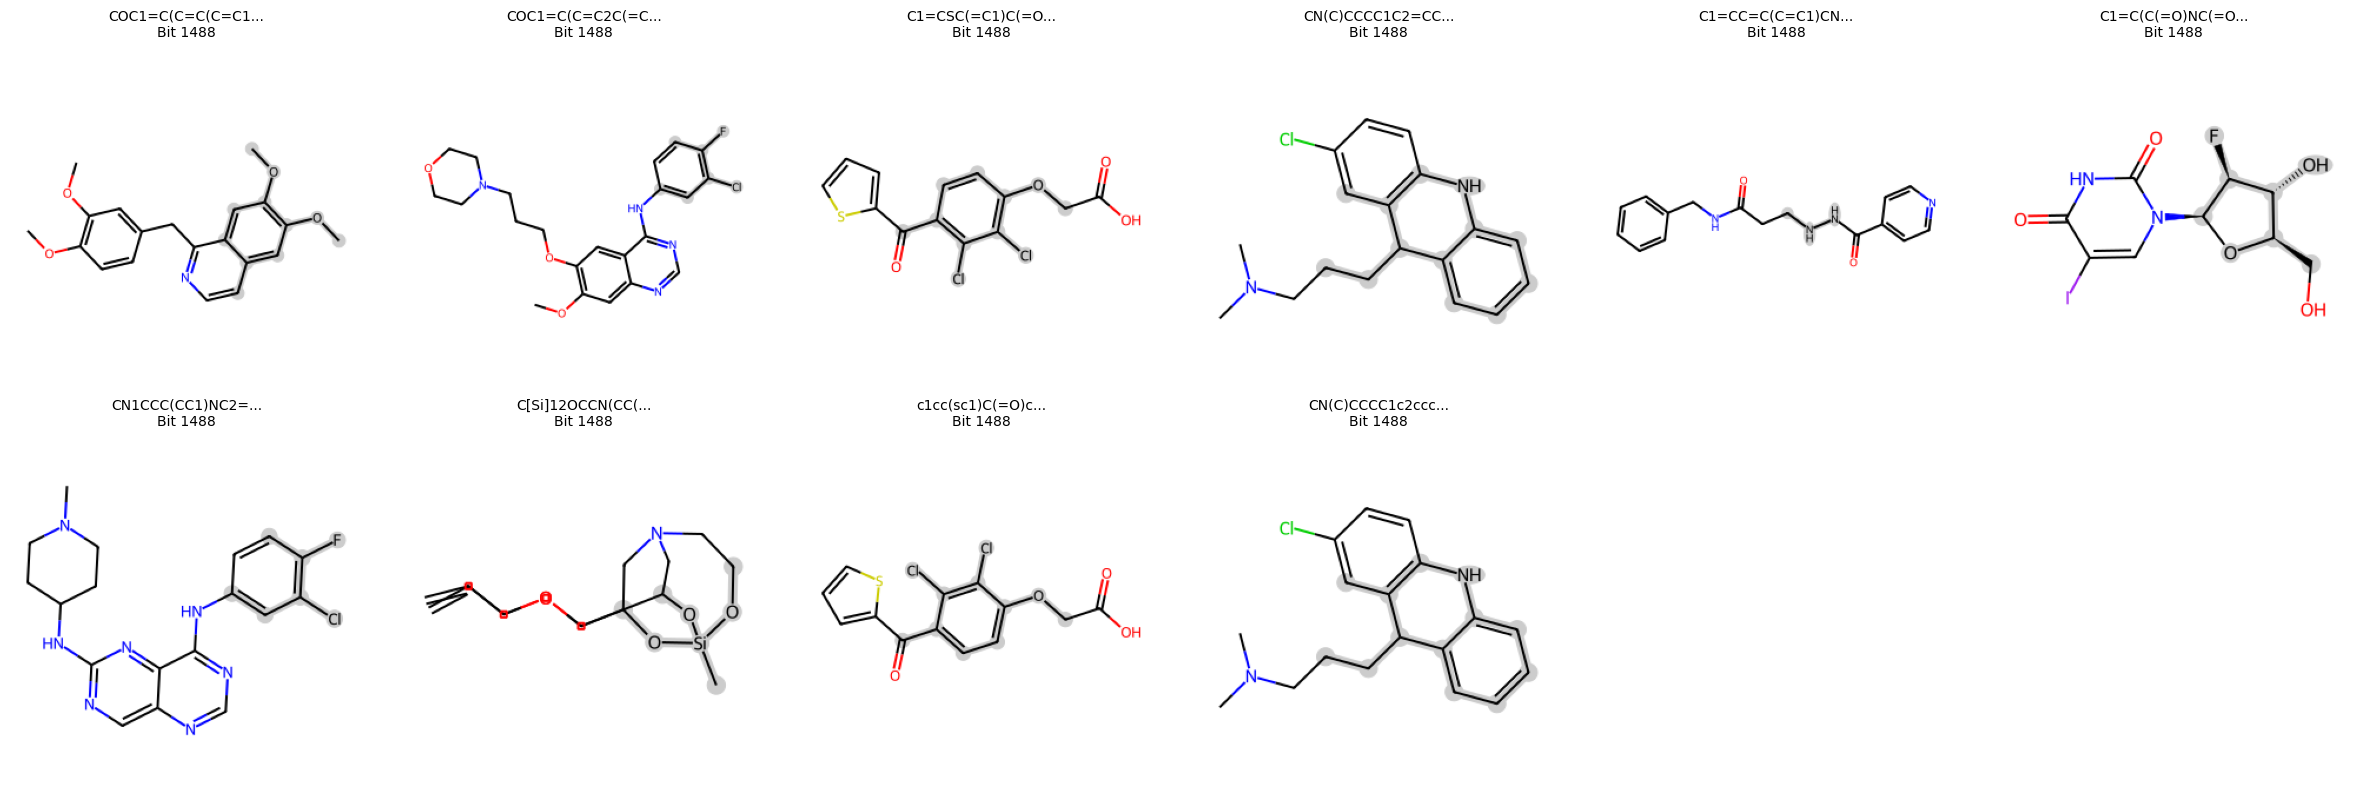

In [55]:
smiles_list = data.index.to_list()[:500]
visualize_bit_substructures(smiles_list, bit_position=1488) #c-c-o-

[00:23:10] DEPRECATION WARNING: please use MorganGenerator
[00:23:10] DEPRECATION WARNING: please use MorganGenerator
[00:23:10] DEPRECATION WARNING: please use MorganGenerator
[00:23:10] DEPRECATION WARNING: please use MorganGenerator
[00:23:10] DEPRECATION WARNING: please use MorganGenerator
[00:23:10] DEPRECATION WARNING: please use MorganGenerator
[00:23:10] DEPRECATION WARNING: please use MorganGenerator
[00:23:10] DEPRECATION WARNING: please use MorganGenerator
[00:23:10] DEPRECATION WARNING: please use MorganGenerator
[00:23:10] DEPRECATION WARNING: please use MorganGenerator
[00:23:10] DEPRECATION WARNING: please use MorganGenerator
[00:23:10] DEPRECATION WARNING: please use MorganGenerator
[00:23:10] DEPRECATION WARNING: please use MorganGenerator
[00:23:10] DEPRECATION WARNING: please use MorganGenerator
[00:23:10] DEPRECATION WARNING: please use MorganGenerator
[00:23:10] DEPRECATION WARNING: please use MorganGenerator
[00:23:10] DEPRECATION WARNING: please use MorganGenerat

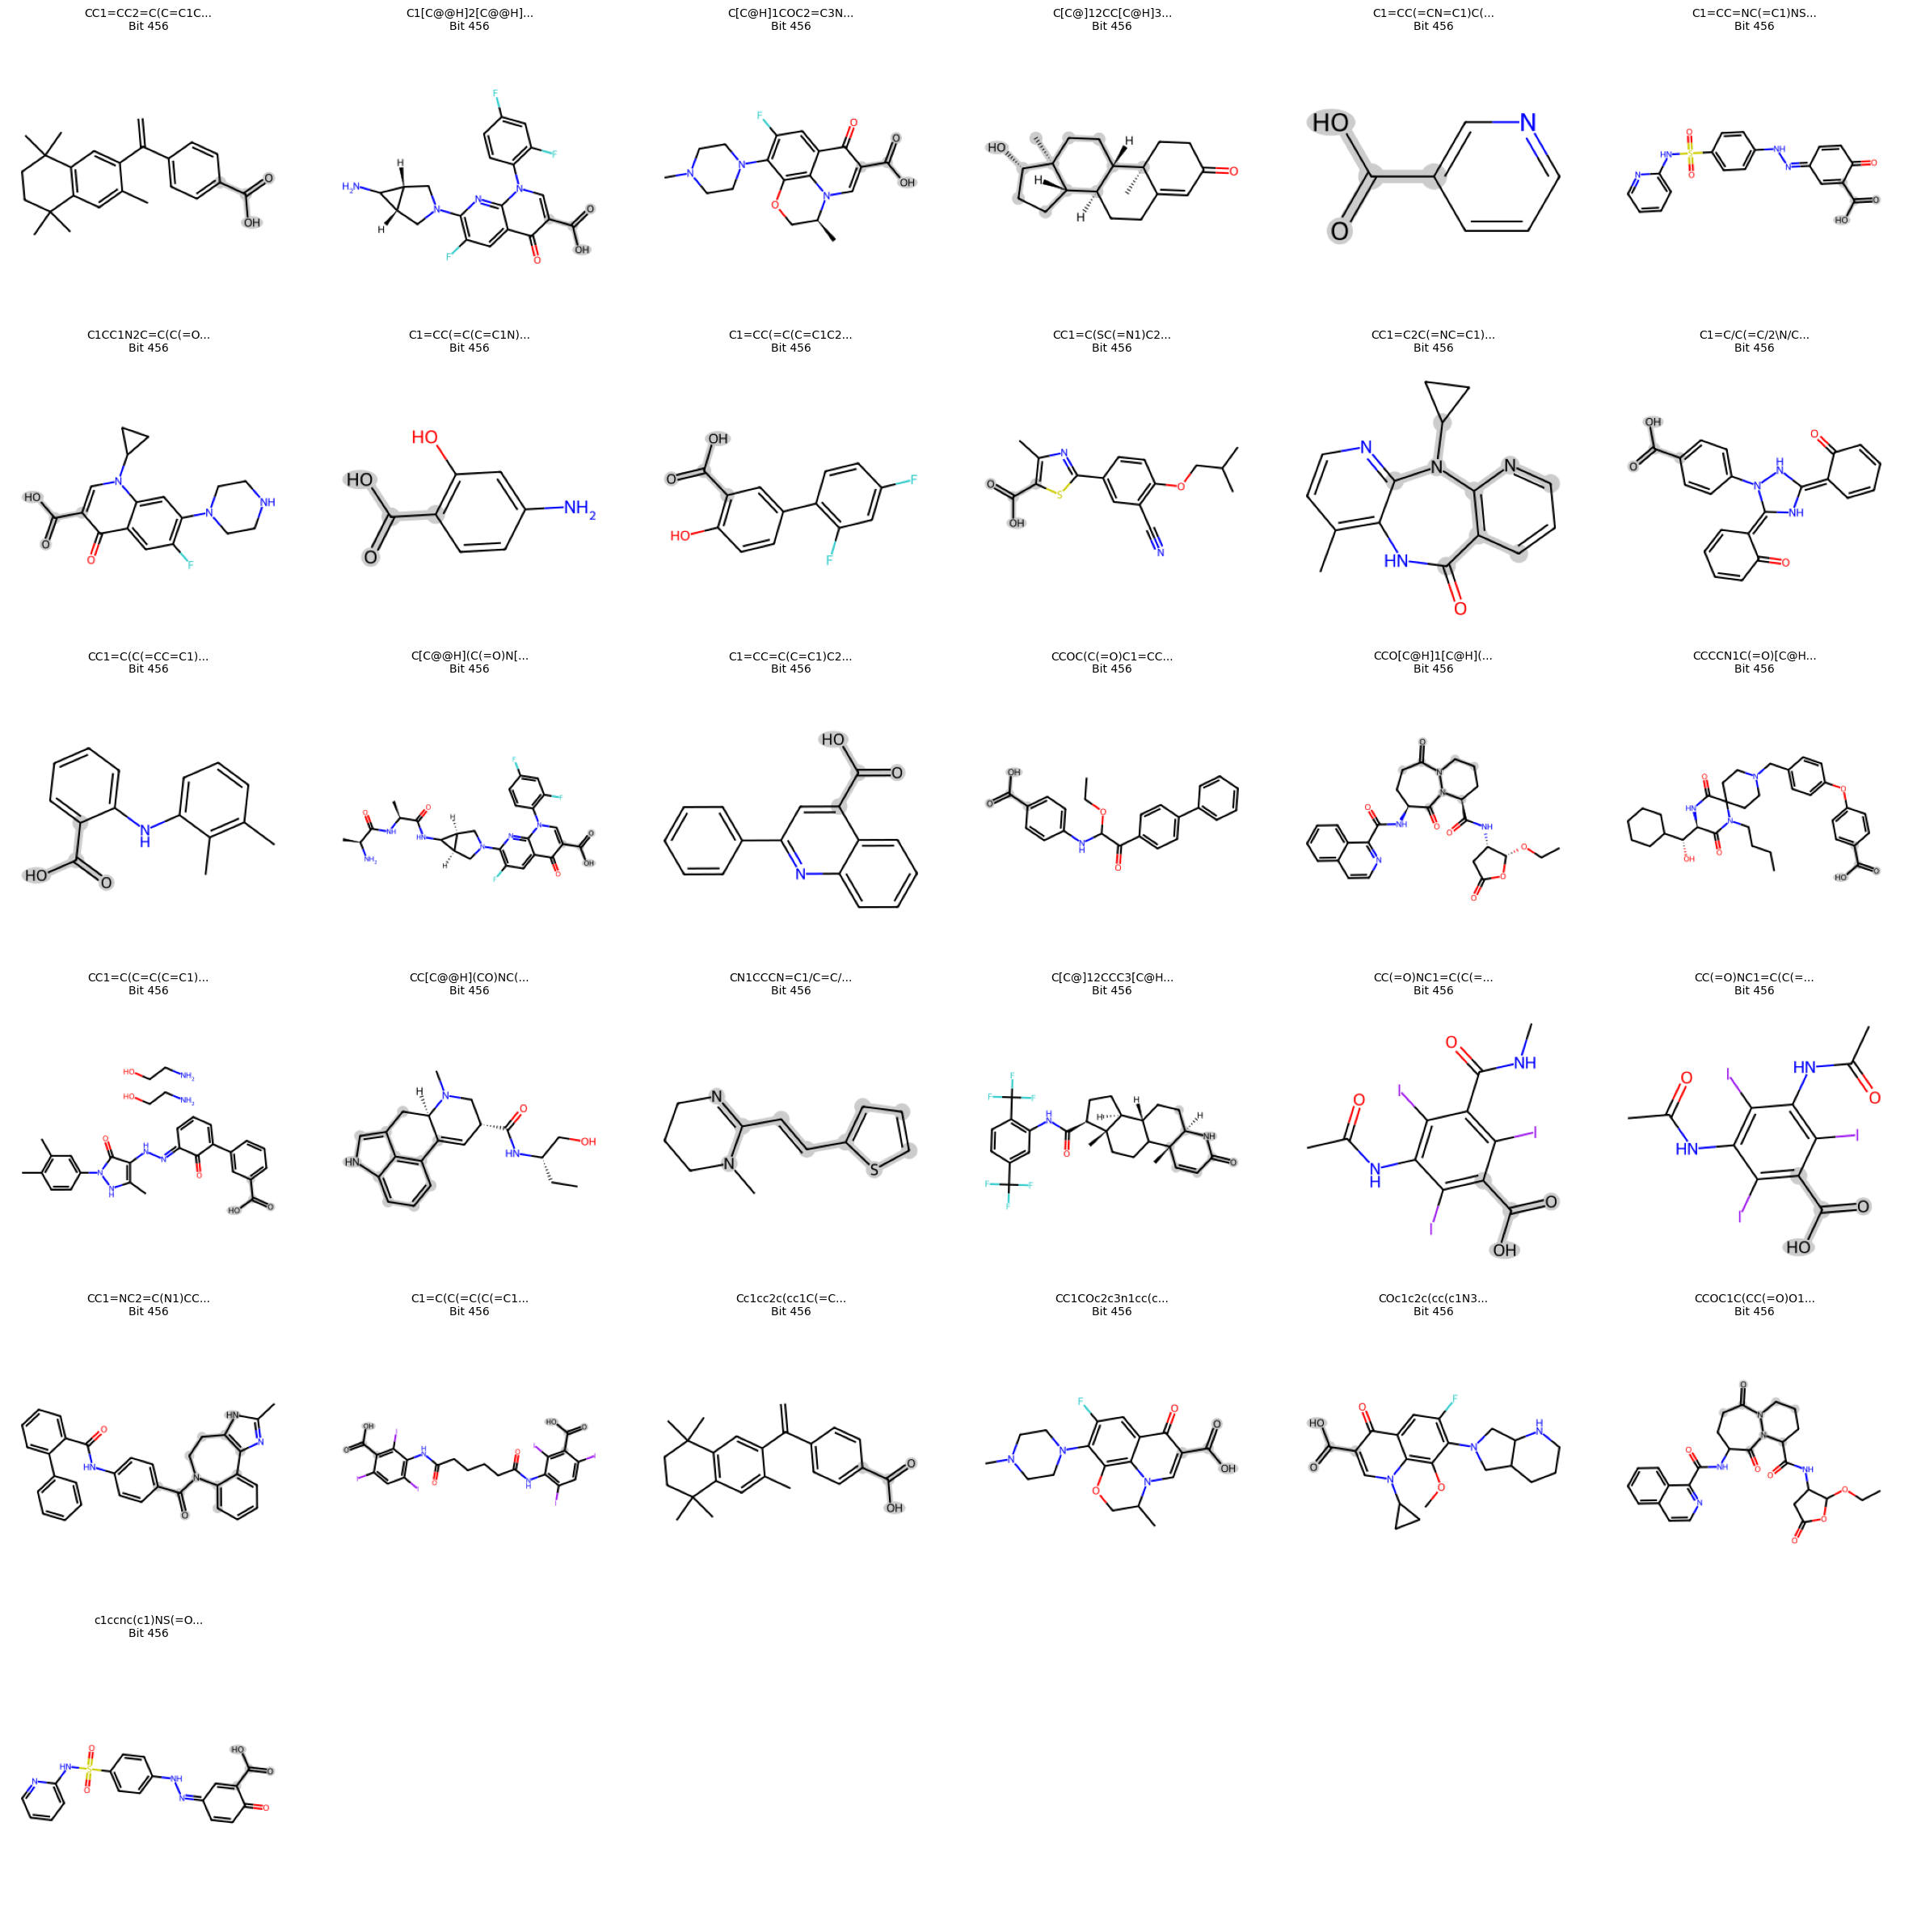

In [56]:
smiles_list = data.index.to_list()[:500]
visualize_bit_substructures(smiles_list, bit_position=456) #c-c-o-